## VISCOELASTICITY COMPLETE PIPELINE

In [ ]:
%matplotlib widget

import os
import cv2
import numpy as np
import numpy as np
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pylab import subplot
from matplotlib.colors import LogNorm
from matplotlib.widgets import SpanSelector
from tqdm.auto import tqdm
from scipy.optimize import leastsq

# Set environment variables for OpenCV
os.environ['OPENCV_LOG_LEVEL'] = 'FATAL'
os.environ['OPENCV_FFMPEG_LOGLEVEL'] = "-8"

In [ ]:
import glob
import numpy as np
from scipy.optimize import least_squares

# 1. Setup paths to all your DDM files
# Change the path and pattern to match your files
file_pattern = r'/Volumes/MyMedia SSD/ISF_only_visco/lycerol/realtime/*_ISF.npz'
files = sorted(glob.glob(file_pattern))

all_Gp = []
all_Gpp = []
all_tau = []
all_qs = [] # To ensure all files share the same q-vectors

print(f"Found {len(files)} files. Starting processing...")

for f_path in files:
    data = np.load(f_path)
    ISF = data['ISF']  
    qs = data['qs']         
    dts = data['dts']       
    tmax = -1
    
    # Check if qs match across files (optional but recommended)
    all_qs.append(qs)
    
    # --- Fitting for this specific file ---
    params = np.zeros((ISF.shape[-1], 3))
    for iq, ddm in enumerate(ISF[:tmax].T):
        B_guess = np.min(ddm[:3]) if len(ddm) > 3 else ddm.min()
        A_guess = np.ptp(ddm)
        tc_guess = 1.0
        
        # model_ddm and residual should be defined as in your current notebook
        res = least_squares(
            residual, 
            x0=[max(A_guess, 1e-6), max(B_guess, 1e-6), tc_guess], 
            bounds=([0, 0, 0], [np.inf, np.inf, np.inf]),
            args=(dts[:tmax], ddm)
        )
        params[iq] = res.x
    
    # Store tau for this file
    all_tau.append(params[:, 2])
    
    # --- Insert your current G' and G'' calculation code here ---
    # This should be the code where you calculate Gp and Gpp from params
    # For example: 
    # Gp, Gpp = calculate_moduli(params, qs, ...) 
    # all_Gp.append(Gp)
    # all_Gpp.append(Gpp)

print("All files processed.")

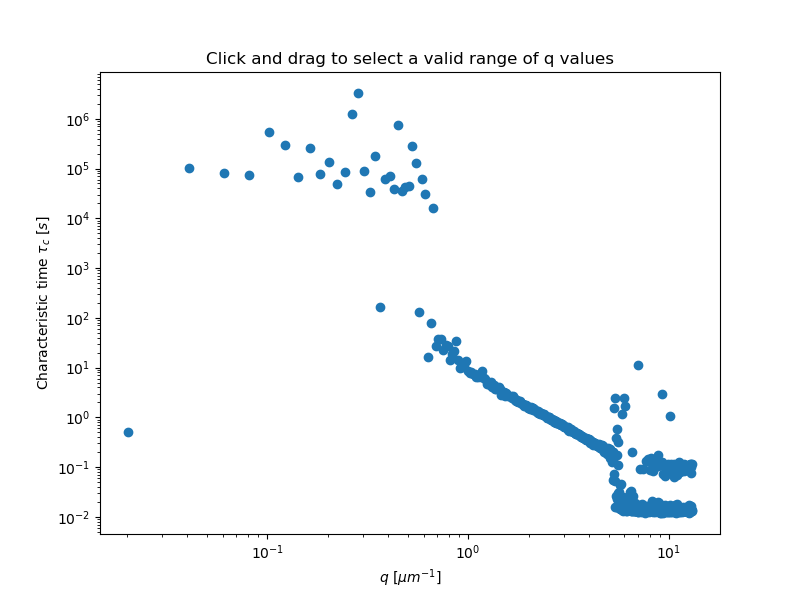

In [ ]:
def onselect(xmin, xmax):
    global iqmin, iqmax
    iqmin= np.searchsorted(qs, xmin)
    iqmax = np.searchsorted(qs, xmax)
    print(f"Selected range: {qs[iqmin]:.2f} to {qs[iqmax]:.2f}")

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(qs, params[:, 2], 'o')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$q\ [\mu m^{-1}$]')
ax.set_ylabel(r'Characteristic time $\tau_c\ [s]$')
ax.set_title('Click and drag to select a valid range of q values')

span = SpanSelector(ax, onselect, 'horizontal', useblit=True, interactive=True, props=dict(alpha=0.5, facecolor='red'))
plt.show()

(1000.0, 100000000000.0)

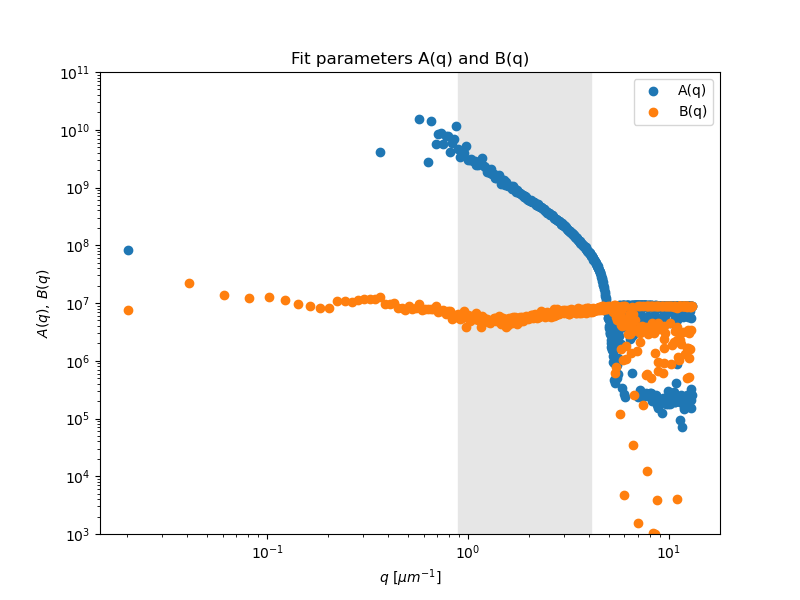

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.title('Fit parameters A(q) and B(q)')
plt.plot(qs, params[:,0], 'o', label="A(q)")
plt.plot(qs, params[:,1], 'o', label="B(q)")
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$q\ [\mu m^{-1}]$')
plt.ylabel(r'$A(q),\, B(q)$')

plt.axvspan(qs[iqmin], qs[iqmax], color=(0.9,0.9,0.9))
plt.legend()
plt.ylim((1e3,1e11))

In [ ]:
import numpy as np

# --- MSD from DDM (model-free once A(q), B(q) are known) ---
# f(q, tau) = 1 - (ISF(q, tau) - B(q)) / A(q)

if iqmax <= iqmin:
    raise ValueError("iqmax must be > iqmin. Select a valid q-range first.")

tau_all = dts[:tmax]
q_sel = qs[iqmin:iqmax]
if np.any(q_sel <= 0):
    raise ValueError("Selected q-range includes q<=0. Choose iqmin>0.")
Aq = params[iqmin:iqmax, 0]
Bq = params[iqmin:iqmax, 1]

f_qtau = 1.0 - (ISF[:tmax, iqmin:iqmax] - Bq) / Aq

# Numerical safety: clip to (0, 1]
eps = 1e-10
f_qtau = np.clip(f_qtau, eps, 1.0)

# Choose MSD convention: 6 for 3D MSD, 4 for 2D in-plane MSD.
msd_factor = 4.0
MSD_qtau = -(msd_factor / (q_sel[None, :] ** 2)) * np.log(f_qtau)

# (Averaging over q is done after selecting a valid tau-range.)

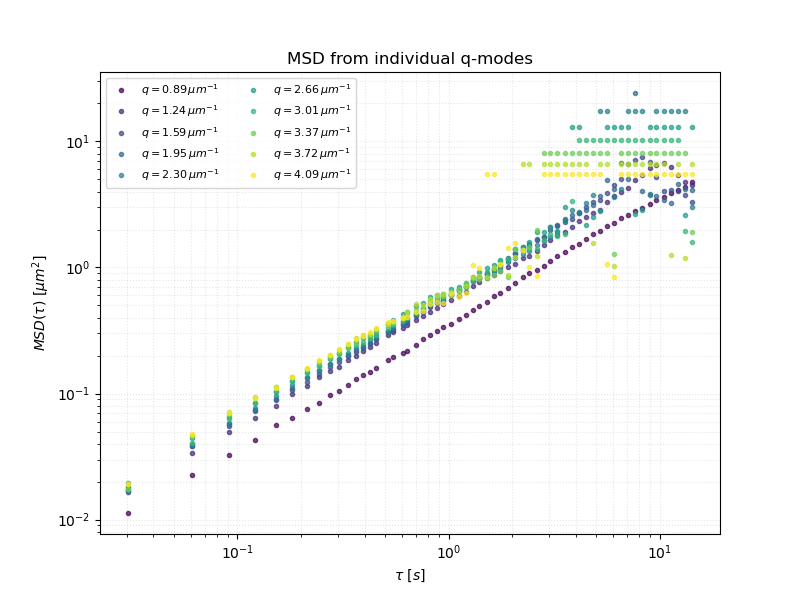

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Plot MSD(tau) for 10 equally spaced q-values in the selected range
n_show = 10
idx_rel = np.linspace(0, len(q_sel) - 1, n_show, dtype=int)
idx_rel = np.unique(idx_rel)
colors = plt.cm.viridis(np.linspace(0, 1, len(idx_rel)))

plt.figure(figsize=(8, 6))
for c, j in zip(colors, idx_rel):
    plt.plot(tau_all, MSD_qtau[:, j], '.', color=c, alpha=0.7, label=rf"$q={q_sel[j]:.2f}\,\mu m^{{-1}}$")
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\tau\ [s]$')
plt.ylabel(r'$MSD(\tau)\ [\mu m^2]$')
plt.title('MSD from individual q-modes')
plt.legend(ncol=2, fontsize=8)
plt.grid(True, which='both', ls=':', alpha=0.3)

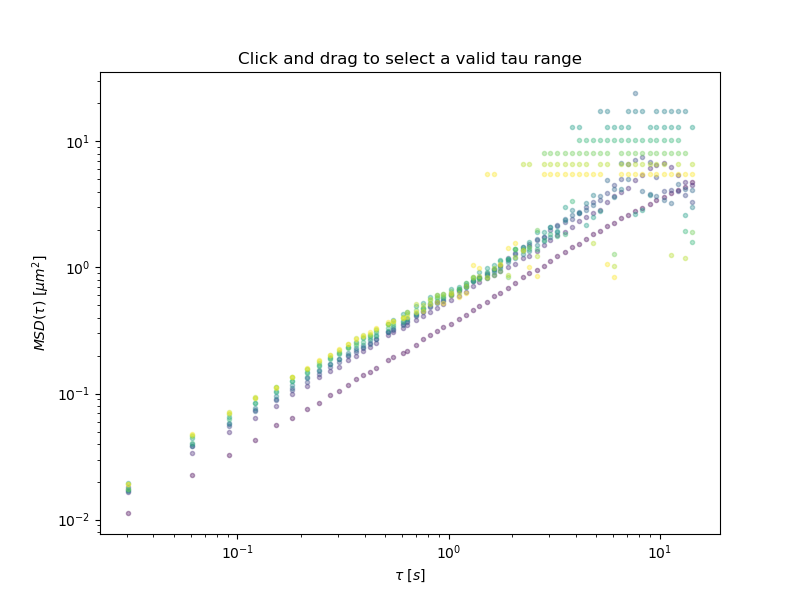

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import SpanSelector

# Default selection: full tau range (override by dragging)
itmin, itmax = 0, len(tau_all)

def onselect_tau(xmin, xmax):
    global itmin, itmax
    xmin, xmax = sorted((xmin, xmax))
    itmin = int(np.searchsorted(tau_all, xmin, side='left'))
    itmax = int(np.searchsorted(tau_all, xmax, side='right'))
    itmin = max(0, min(itmin, len(tau_all) - 1))
    itmax = max(itmin + 1, min(itmax, len(tau_all)))
    print(f"Selected tau range: {tau_all[itmin]:.3g} to {tau_all[itmax-1]:.3g} s (indices {itmin}:{itmax})")

# Plot a subset of q-modes to help choose a tau-window where MSD collapses
n_show = 10
idx_rel = np.linspace(0, len(q_sel) - 1, n_show, dtype=int)
idx_rel = np.unique(idx_rel)
colors = plt.cm.viridis(np.linspace(0, 1, len(idx_rel)))

fig, ax = plt.subplots(figsize=(8, 6))
for c, j in zip(colors, idx_rel):
    ax.plot(tau_all, MSD_qtau[:, j], '.', color=c, alpha=0.35)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$\tau\ [s]$')
ax.set_ylabel(r'$MSD(\tau)\ [\mu m^2]$')
ax.set_title('Click and drag to select a valid tau range')
span_tau = SpanSelector(ax, onselect_tau, 'horizontal', useblit=True, interactive=True, props=dict(alpha=0.3, facecolor='red'))
plt.show()

Using tau range: 0.121 to 1.12 s (indices 3:26)


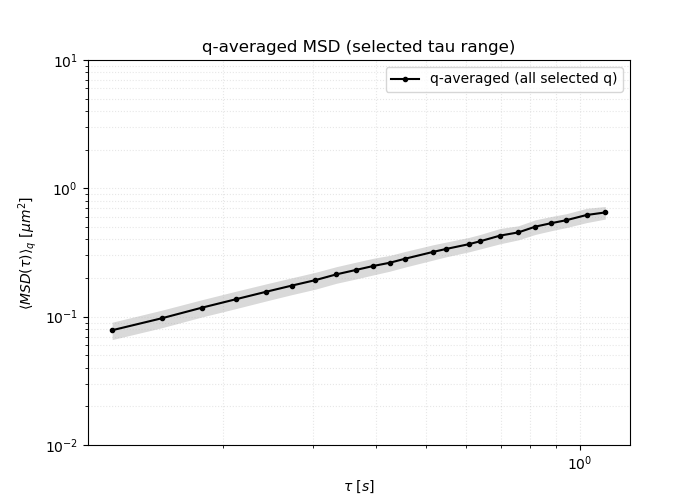

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Fallback if the interactive selector hasn't been used yet
if 'itmin' not in globals() or 'itmax' not in globals():
    itmin, itmax = 0, len(tau_all)

tau = tau_all[itmin:itmax]
MSD_qtau_sel = MSD_qtau[itmin:itmax, :]

# Average over all selected q
MSD_avg = np.nanmean(MSD_qtau_sel, axis=1)
MSD_std = np.nanstd(MSD_qtau_sel, axis=1)

print(f"Using tau range: {tau[0]:.3g} to {tau[-1]:.3g} s (indices {itmin}:{itmax})")

plt.figure(figsize=(7, 5))
plt.plot(tau, MSD_avg, 'k.-', label='q-averaged (all selected q)')
msd_floor = np.finfo(float).tiny
plt.fill_between(tau, np.maximum(MSD_avg - MSD_std, msd_floor), MSD_avg + MSD_std, color='k', alpha=0.15, linewidth=0)
plt.xscale('log')
plt.ylim(10**-2,10**1)
plt.yscale('log')
plt.xlabel(r'$\tau\ [s]$')
plt.ylabel(r'$\langle MSD(\tau) \rangle_q\ [\mu m^2]$')
plt.title('q-averaged MSD (selected tau range)')
plt.legend()
plt.grid(True, which='both', ls=':', alpha=0.3)

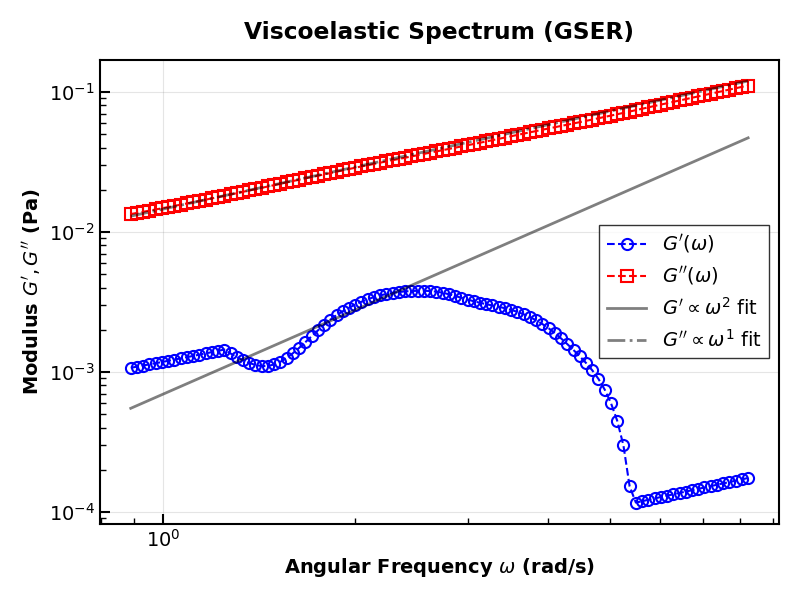

In [ ]:
# --- REPLACEMENT FOR CELL 60: Publishable GSER Pipeline with Terminal Fits ---
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit

# --- 1. Physical Constants & Experimental Parameters ---
kb = 1.380649e-23      
T_kelvin = 23.0 + 273.15 
radius_m = 150e-9      # *** CHANGE TO YOUR ACTUAL TRACER RADIUS (meters) ***

# --- 2. Data Prep & Cleaning ---
valid = np.isfinite(tau) & (tau > 0) & np.isfinite(MSD_avg) & (MSD_avg > 0)
tau_v = tau[valid]
msd_v = MSD_avg[valid] * 1e-12 # Convert from um^2 (DDM standard) to m^2

# Ensure strictly increasing for interpolation
order_tau = np.argsort(tau_v)
tau_v = tau_v[order_tau]
msd_v = msd_v[order_tau]

log_tau_raw = np.log(tau_v)
log_msd_raw = np.log(msd_v)

# --- 3. Interpolation onto a UNIFORM log grid ---
num_points = 100 
log_tau_uniform = np.linspace(log_tau_raw.min(), log_tau_raw.max(), num_points)

interpolator = interp1d(log_tau_raw, log_msd_raw, kind='linear')
log_msd_uniform = interpolator(log_tau_uniform)

# --- 4. Smoothing and Derivative ---
win = 31 
poly = 2
dlogtau = log_tau_uniform[1] - log_tau_uniform[0] 

log_msd_smooth = savgol_filter(log_msd_uniform, window_length=win, polyorder=poly)
alpha = savgol_filter(log_msd_smooth, window_length=win, polyorder=1, deriv=1, delta=dlogtau)

# Soft boundaries to prevent math crashes, but preserve actual liquid/solid physics
alpha = np.clip(alpha, 0.001, 0.999)

# --- 5. Transform back to physical variables ---
omega = 1.0 / np.exp(log_tau_uniform)
msd_smooth = np.exp(log_msd_smooth)

# GSER Calculation
prefactor = (kb * T_kelvin) / (np.pi * radius_m * msd_smooth * gamma(1.0 + alpha))
Gp = prefactor * np.cos(np.pi * alpha / 2.0)
Gpp = prefactor * np.sin(np.pi * alpha / 2.0)

# Sort by frequency for plotting & fitting
order = np.argsort(omega)
omega = omega[order]
Gp = Gp[order]
Gpp = Gpp[order]

# --- 6. Terminal Regime Fitting (Maxwell Power Laws) ---
# We fit the low frequency (terminal) region. Let's take the first 30% of omega points.
fit_idx = int(len(omega) * 0.3)
omega_fit = omega[:fit_idx]
Gp_fit_data = Gp[:fit_idx]
Gpp_fit_data = Gpp[:fit_idx]

# Define the theoretical power laws for terminal regime
def fit_Gp_model(w, K): return K * (w ** 2)
def fit_Gpp_model(w, K): return K * (w ** 1)

# Fit G' ~ omega^2
try:
    popt_Gp, _ = curve_fit(fit_Gp_model, omega_fit, Gp_fit_data, p0=[Gp_fit_data[0]/(omega_fit[0]**2)])
    Gp_trend = fit_Gp_model(omega, *popt_Gp)
    gp_fit_success = True
except:
    gp_fit_success = False

# Fit G'' ~ omega^1
try:
    popt_Gpp, _ = curve_fit(fit_Gpp_model, omega_fit, Gpp_fit_data, p0=[Gpp_fit_data[0]/omega_fit[0]])
    Gpp_trend = fit_Gpp_model(omega, *popt_Gpp)
    gpp_fit_success = True
except:
    gpp_fit_success = False

# --- 7. Publishable Plotting ---
plt.rcParams.update({'font.size': 14, 'axes.linewidth': 1.5})
fig, ax = plt.subplots(figsize=(8, 6))

# Plot raw GSER data with hollow points and dashed lines
ax.loglog(omega, Gp, marker='o', linestyle='--', color='blue', mfc='none', markersize=8, markeredgewidth=1.5, label=r"$G'(\omega)$")
ax.loglog(omega, Gpp, marker='s', linestyle='--', color='red', mfc='none', markersize=8, markeredgewidth=1.5, label=r"$G''(\omega)$")

# Plot the theoretical trendlines
if gp_fit_success:
    ax.loglog(omega, Gp_trend, linestyle='-', color='black', alpha=0.5, linewidth=2, label=r"$G' \propto \omega^2$ fit")
if gpp_fit_success:
    ax.loglog(omega, Gpp_trend, linestyle='-.', color='black', alpha=0.5, linewidth=2, label=r"$G'' \propto \omega^1$ fit")

# Formatting
ax.set_xlabel(r'Angular Frequency $\omega$ (rad/s)', fontweight='bold')
ax.set_ylabel(r'Modulus $G^\prime, G^{\prime\prime}$ (Pa)', fontweight='bold')
ax.set_title('Viscoelastic Spectrum (GSER)', fontweight='bold', pad=15)

# Ticks and Grid
ax.tick_params(axis='both', which='major', length=7, width=1.5, direction='in')
ax.tick_params(axis='both', which='minor', length=4, width=1, direction='in')
ax.grid(True, which='major', linestyle='-', alpha=0.2, color='gray')

# Legend
ax.legend(loc='best', frameon=True, edgecolor='black', fancybox=False)

plt.tight_layout()
plt.show()